# Modelos — STARWARS_AUTOCALLS

Entrenamiento, comparación y explicación de los modelos que predicen `avg_duration_months`.

| Bloque | Qué hace |
|---|---|
| 0 | Setup |
| 1 | Carga y contrato de features |
| 2 | Corte temporal: pasado para entrenar, futuro para evaluar |
| 3 | Referencias sin modelo (los dos baselines) |
| 4 | Cuánto aporta el plazo, y por qué predecimos el ratio |
| 5 | Modelo principal: CatBoost sobre el ratio |
| 6 | GAM explicativo |
| 7 | Comparación con intervalos de confianza |
| 8 | Backtest de origen deslizante |
| 9 | Bandas de incertidumbre P10–P90 |
| 10 | Interpretabilidad (SHAP) |
| 11 | Guardado de artefactos |

## 0. Setup

Semilla fija, rutas y directorios de artefactos.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer, StandardScaler

RANDOM_SEED = 42
TARGET = "avg_duration_months"
MATURITY = "nominal_maturity_months"
HOLDOUT_DAYS = 180

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "data" / "processed").exists() else cwd.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
BASELINE_DIR = MODELS_DIR / "baseline"
GAM_DIR = MODELS_DIR / "gam"
CATBOOST_DIR = MODELS_DIR / "catboost"
REPORTS_DIR = MODELS_DIR / "reports"
for directory in [BASELINE_DIR, GAM_DIR, CATBOOST_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Proyecto  : {PROJECT_ROOT}")
print(f"Artefactos: {MODELS_DIR}")

Proyecto  : /home/kiril/Proyectos/starwars_autocalls
Artefactos: /home/kiril/Proyectos/starwars_autocalls/models


## 1. Carga y contrato de features

Los asserts comprueban que lo que llega es lo que esperamos: solo RFQ ejecutadas, sin nulos, sin
texto y con el plazo dentro del contrato.

In [2]:
data = pd.read_csv(
    PROCESSED_DIR / "train_features.csv",
    parse_dates=["requested_date", "start_date", "end_date"],
)
feature_columns = pd.read_csv(PROCESSED_DIR / "model_feature_columns.csv")["feature_name"].tolist()

assert data["executed"].all(), "train_features debe contener solo RFQs ejecutadas"
assert data[TARGET].notna().all(), "El entrenamiento requiere target observado"
assert set(feature_columns).issubset(data.columns), "El contrato pide columnas que no están"
assert data[feature_columns].select_dtypes(include="object").empty, "Las features deben ser numéricas"
assert not data[feature_columns].isna().any().any(), "Hay nulos en las features"
assert MATURITY in feature_columns, "El plazo debe formar parte del contrato"

# El ratio es la parametrizacion del target, no una feature: nunca entra en X.
data["duration_ratio"] = data[TARGET] / data[MATURITY]
assert "duration_ratio" not in feature_columns

print(f"RFQ ejecutadas : {len(data):,}")
print(f"Periodo        : {data.requested_date.min():%Y-%m-%d} a {data.requested_date.max():%Y-%m-%d}")
print(f"Features       : {len(feature_columns)}")
print()
print(f"Duración  (meses): media {data[TARGET].mean():.2f} | std {data[TARGET].std():.2f}")
print(f"Plazo     (meses): media {data[MATURITY].mean():.2f} | std {data[MATURITY].std():.2f}")
print(f"Ratio duración/plazo: media {data['duration_ratio'].mean():.3f} | std {data['duration_ratio'].std():.3f}")

RFQ ejecutadas : 13,796
Periodo        : 2016-01-04 a 2024-06-28
Features       : 91

Duración  (meses): media 39.78 | std 22.11
Plazo     (meses): media 71.95 | std 27.72
Ratio duración/plazo: media 0.579 | std 0.245


/tmp/ipykernel_22125/1961874565.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["duration_ratio"] = data[TARGET] / data[MATURITY]


## 2. Corte temporal

Para entrenal el modelo hacemos un corte temporal. Entrenamos antes de una fecha y predecimos a partir de esta. Sin cortes aleatorios porque es una serie temporal.

In [3]:
test_start = data["requested_date"].max().normalize() - pd.Timedelta(days=HOLDOUT_DAYS - 1)
train = data.loc[data["requested_date"] < test_start].copy()
test = data.loc[data["requested_date"] >= test_start].copy()

assert train["requested_date"].max() < test["requested_date"].min()
assert len(train) and len(test)

y_train, y_test = train[TARGET], test[TARGET]
ratio_train = train["duration_ratio"]

# Techo del ratio, calculado SOLO con train. Sirve para no dejar que el modelo
# prediga duraciones por encima de lo que se ha observado nunca.
RATIO_CAP = float(ratio_train.max())

print(pd.DataFrame({
    "split": ["train (pasado)", "test (futuro reservado)"],
    "n_rfqs": [len(train), len(test)],
    "desde": [train.requested_date.min().date(), test.requested_date.min().date()],
    "hasta": [train.requested_date.max().date(), test.requested_date.max().date()],
}).to_string(index=False))
print()
print(f"Techo del ratio observado en train: {RATIO_CAP:.3f}")

                  split  n_rfqs      desde      hasta
         train (pasado)   13050 2016-01-04 2023-12-29
test (futuro reservado)     746 2024-01-01 2024-06-28

Techo del ratio observado en train: 1.203


## 3. Referencias sin modelo

Para determinar si el modelo es bueno vamos a usar una mediana global y baseline temporal para poder tener una umbral de decir si es bueno o no

In [4]:
# 1) Mediana global.
median_train = float(y_train.median())
pred_median = np.full(len(test), median_train)

# 2) Baseline estructural: fraccion media del plazo, calculada solo con train.
mean_ratio_train = float(ratio_train.mean())
pred_structural = mean_ratio_train * test[MATURITY].to_numpy()

print(f"Mediana de duración en train        : {median_train:.2f} meses")
print(f"Fracción media del plazo en train   : {mean_ratio_train:.3f}")
print()
print(f"MAE mediana global                  : {mean_absolute_error(y_test, pred_median):.3f} meses")
print(f"MAE baseline estructural            : {mean_absolute_error(y_test, pred_structural):.3f} meses")
print()
print(f"Lectura de negocio: sin modelo, la mesa asumiría que un producto vive el "
      f"{mean_ratio_train:.0%} de su plazo.")

Mediana de duración en train        : 35.39 meses
Fracción media del plazo en train   : 0.580

MAE mediana global                  : 18.107 meses
MAE baseline estructural            : 15.127 meses

Lectura de negocio: sin modelo, la mesa asumiría que un producto vive el 58% de su plazo.


## 4. Cuánto aporta el plazo, y por qué predecimos el ratio

Entrenamos 3 modelos
1- Entrenar con plazo y predecir los meses de la duracion
2- Entrenar con ratio y predecir los meses de la duracion
3. Entrenar con ambos y predecir fracción del plazo

In [5]:
CATBOOST_PARAMS = dict(
    loss_function="MAE", eval_metric="MAE",
    iterations=800, learning_rate=0.05, depth=8, l2_leaf_reg=5.0,
    random_seed=RANDOM_SEED, verbose=False, allow_writing_files=False,
)

def fit_catboost(X, y, **overrides):
    """Entrena CatBoost con la configuracion fija del proyecto."""
    model = CatBoostRegressor(**{**CATBOOST_PARAMS, **overrides})
    model.fit(X, y)
    return model

def ratio_to_months(model, frame, columns, cap):
    """Convierte la prediccion de ratio en meses, sin pasarse del techo observado."""
    ratio = np.clip(model.predict(frame[columns]), 0.0, cap)
    return ratio * frame[MATURITY].to_numpy()

features_sin_plazo = [c for c in feature_columns if c != MATURITY]

model_a = fit_catboost(train[features_sin_plazo], y_train)
pred_a = model_a.predict(test[features_sin_plazo])

model_b = fit_catboost(train[feature_columns], y_train)
pred_b = model_b.predict(test[feature_columns])

model_c = fit_catboost(train[feature_columns], ratio_train)
pred_c = ratio_to_months(model_c, test, feature_columns, RATIO_CAP)

ablation = pd.DataFrame([
    {"variante": "A - sin el plazo", "n_features": len(features_sin_plazo),
     "MAE_meses": mean_absolute_error(y_test, pred_a)},
    {"variante": "B - con el plazo, predice meses", "n_features": len(feature_columns),
     "MAE_meses": mean_absolute_error(y_test, pred_b)},
    {"variante": "C - con el plazo, predice ratio", "n_features": len(feature_columns),
     "MAE_meses": mean_absolute_error(y_test, pred_c)},
])
print(ablation.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print(f"Añadir el plazo        : {ablation.MAE_meses.iloc[0] - ablation.MAE_meses.iloc[1]:+.3f} meses de MAE")
print(f"Reparametrizar a ratio : {ablation.MAE_meses.iloc[1] - ablation.MAE_meses.iloc[2]:+.3f} meses de MAE")

                       variante  n_features  MAE_meses
               A - sin el plazo          90     11.313
B - con el plazo, predice meses          91      4.023
C - con el plazo, predice ratio          91      4.017

Añadir el plazo        : +7.290 meses de MAE
Reparametrizar a ratio : +0.006 meses de MAE


Añadimos el plazo 100%

In [6]:
# La misma variable, correlacionada contra el target crudo y contra el ratio.
comparacion = pd.DataFrame({
    "corr_con_duracion": data[feature_columns].corrwith(data[TARGET]),
    "corr_con_ratio": data[feature_columns].corrwith(data["duration_ratio"]),
})
destacadas = ["basket_size", "realized_vol_range", "protection_barrier_pct",
              "observation_frequency_months", "no_call_period_months"]
print("Correlación de cada variable con el target crudo y con el ratio:")
print(comparacion.loc[[c for c in destacadas if c in comparacion.index]].round(3).to_string())
print()
print("El sentido de negocio del efecto worst-of, medido sobre el ratio:")
print(
    data.groupby("basket_size")["duration_ratio"]
    .agg(n_rfqs="size", ratio_medio="mean").round(3)
    .rename_axis("subyacentes en la cesta")
)
print()
print("Más subyacentes -> el peor de la cesta está más abajo -> cuesta más superar la barrera")
print("-> el producto vive una fracción mayor de su plazo.")

Correlación de cada variable con el target crudo y con el ratio:
                              corr_con_duracion  corr_con_ratio
basket_size                               0.336           0.393
realized_vol_range                        0.343           0.403
protection_barrier_pct                   -0.340          -0.389
observation_frequency_months              0.205           0.260
no_call_period_months                     0.085           0.104

El sentido de negocio del efecto worst-of, medido sobre el ratio:
                         n_rfqs  ratio_medio
subyacentes en la cesta                     
1                          4666        0.438
2                          6826        0.638
3                          2304        0.690

Más subyacentes -> el peor de la cesta está más abajo -> cuesta más superar la barrera
-> el producto vive una fracción mayor de su plazo.


## 5. Modelo principal: CatBoost sobre el ratio

LEntrenamos el modelo de producción con todo sin buscar hiperparámetros:
Métrica MAE

In [7]:
model_primary = model_c          # ya entrenado en el bloque anterior
pred_primary = pred_c

print(f"Modelo principal: CatBoost sobre el ratio, {len(feature_columns)} features")
print(f"MAE  : {mean_absolute_error(y_test, pred_primary):.3f} meses")
print(f"RMSE : {root_mean_squared_error(y_test, pred_primary):.3f} meses")
print()
print("Predicciones frente a lo observado (primeras 8 RFQ del holdout):")
print(pd.DataFrame({
    "plazo": test[MATURITY].to_numpy(),
    "real": y_test.to_numpy(),
    "predicho": pred_primary,
    "error": y_test.to_numpy() - pred_primary,
}).head(8).round(2).to_string(index=False))

Modelo principal: CatBoost sobre el ratio, 91 features
MAE  : 4.017 meses
RMSE : 5.694 meses

Predicciones frente a lo observado (primeras 8 RFQ del holdout):
 plazo  real  predicho  error
 95.01 14.91     18.67  -3.76
 27.37 23.49     21.51   1.98
 25.69 19.26     18.64   0.62
118.27 16.88      9.12   7.76
 73.98 35.78     32.81   2.97
 76.12 29.19     30.54  -1.35
 61.10 54.93     54.99  -0.06
 39.13 37.07     37.96  -0.89


## 6. GAM explicativo

Un modelo aditivo con splines para las variables continuas y términos lineales para las dummies.
No compite con CatBoost: existe para poder leer los efectos uno a uno, sin interacciones.

In [8]:
gam_spline_columns = [
    "autocall_barrier_pct", "protection_barrier_pct", "no_call_period_months",
    "observation_frequency_months", "quoted_implied_vol", "log_notional_credits",
    "basket_size", "realized_vol_mean", "realized_vol_range",
    "structural_base_vol_mean", "structural_base_vol_range",
    "requested_month_sin", "requested_month_cos", "requested_dayofweek",
    MATURITY,
]
gam_spline_columns = [c for c in gam_spline_columns if c in feature_columns]
gam_linear_columns = [c for c in feature_columns if c not in gam_spline_columns]

gam = Pipeline([
    ("features", ColumnTransformer([
        ("spline", SplineTransformer(n_knots=5, degree=3, extrapolation="linear"), gam_spline_columns),
        ("linear", StandardScaler(), gam_linear_columns),
    ], remainder="drop")),
    ("regressor", Ridge(alpha=10.0)),
])
gam.fit(train[feature_columns], ratio_train)
pred_gam = ratio_to_months(gam, test, feature_columns, RATIO_CAP)

print(f"Splines: {len(gam_spline_columns)} | Términos lineales: {len(gam_linear_columns)}")
print(f"MAE del GAM: {mean_absolute_error(y_test, pred_gam):.3f} meses")

Splines: 15 | Términos lineales: 76
MAE del GAM: 6.867 meses


## 7. Comparación con intervalos de confianza

Una tabla de MAE sin intervalo invita a leer diferencias que no existen. Con 746 filas de holdout,
el error estándar del MAE ronda el medio mes: **dos modelos que se llevan 0.2 meses son
indistinguibles**, y ordenarlos como si uno fuese mejor es sobre-interpretar el ruido.

El intervalo se calcula por bootstrap: se remuestrean las filas del holdout 2.000 veces y se mira
cómo se mueve el MAE.

In [9]:
def bootstrap_mae_ci(y_true, y_pred, n_samples=2000, seed=RANDOM_SEED):
    """Intervalo de confianza al 95% del MAE, remuestreando las filas del holdout."""
    rng = np.random.default_rng(seed)
    errors = np.abs(np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float))
    draws = errors[rng.integers(0, len(errors), size=(n_samples, len(errors)))].mean(axis=1)
    return float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))

candidatos = {
    "Mediana global": pred_median,
    "Baseline estructural (ratio x plazo)": pred_structural,
    "CatBoost sin el plazo": pred_a,
    "GAM sobre el ratio": pred_gam,
    "CatBoost sobre el ratio (principal)": pred_primary,
}

filas = []
for nombre, pred in candidatos.items():
    low, high = bootstrap_mae_ci(y_test, pred)
    filas.append({
        "modelo": nombre,
        "MAE_meses": mean_absolute_error(y_test, pred),
        "IC95_bajo": low,
        "IC95_alto": high,
        "RMSE_meses": root_mean_squared_error(y_test, pred),
    })
metrics = pd.DataFrame(filas).sort_values("MAE_meses").reset_index(drop=True)
metrics.to_csv(REPORTS_DIR / "holdout_metrics.csv", index=False)
print(metrics.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
mejora = mean_absolute_error(y_test, pred_structural) - mean_absolute_error(y_test, pred_primary)
print(f"El modelo principal mejora al baseline estructural en {mejora:.2f} meses de MAE.")

                              modelo  MAE_meses  IC95_bajo  IC95_alto  RMSE_meses
 CatBoost sobre el ratio (principal)      4.017      3.719      4.300       5.694
                  GAM sobre el ratio      6.867      6.450      7.257       8.988
               CatBoost sin el plazo     11.313     10.594     12.082      15.429
Baseline estructural (ratio x plazo)     15.127     14.273     16.080      19.871
                      Mediana global     18.107     17.227     19.045      22.312

El modelo principal mejora al baseline estructural en 11.11 meses de MAE.


## 8. Backtest de origen deslizante

Repetimos el ejercicio con 5 ventanas deslizantes distintas (distintos timepos) para obtener algo más representativo

In [10]:
BACKTEST_FOLDS = 5
FOLD_MONTHS = 6

ultima_fecha = data["requested_date"].max().normalize()
bordes = [ultima_fecha - pd.DateOffset(months=FOLD_MONTHS * i) for i in range(BACKTEST_FOLDS, -1, -1)]

filas = []
for i in range(BACKTEST_FOLDS):
    inicio, fin = bordes[i], bordes[i + 1]
    fold_train = data.loc[data["requested_date"] <= inicio]
    fold_test = data.loc[(data["requested_date"] > inicio) & (data["requested_date"] <= fin)]
    if len(fold_test) < 50:
        continue

    fold_cap = float(fold_train["duration_ratio"].max())
    fold_y = fold_test[TARGET]

    sin_plazo = fit_catboost(fold_train[features_sin_plazo], fold_train[TARGET])
    con_ratio = fit_catboost(fold_train[feature_columns], fold_train["duration_ratio"])

    filas.append({
        "ventana": f"{inicio.date()} -> {fin.date()}",
        "n_train": len(fold_train),
        "n_test": len(fold_test),
        "MAE_estructural": mean_absolute_error(
            fold_y, fold_train["duration_ratio"].mean() * fold_test[MATURITY].to_numpy()),
        "MAE_sin_plazo": mean_absolute_error(fold_y, sin_plazo.predict(fold_test[features_sin_plazo])),
        "MAE_principal": mean_absolute_error(
            fold_y, ratio_to_months(con_ratio, fold_test, feature_columns, fold_cap)),
    })

backtest = pd.DataFrame(filas)
backtest.to_csv(REPORTS_DIR / "backtest_metrics.csv", index=False)
print(backtest.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("Media sobre las ventanas:")
for col in ["MAE_estructural", "MAE_sin_plazo", "MAE_principal"]:
    print(f"  {col:<18} {backtest[col].mean():6.3f} meses  (desviación entre ventanas {backtest[col].std():.3f})")
print()
gana = (backtest["MAE_principal"] < backtest["MAE_sin_plazo"]).sum()
print(f"El modelo con plazo gana en {gana} de {len(backtest)} ventanas.")

                 ventana  n_train  n_test  MAE_estructural  MAE_sin_plazo  MAE_principal
2021-12-28 -> 2022-06-28     9786     802           15.281         10.730          2.372
2022-06-28 -> 2022-12-28    10588     785           14.874         11.744          4.360
2022-12-28 -> 2023-06-28    11373     794           14.796         11.431          2.458
2023-06-28 -> 2023-12-28    12167     876           15.205         10.792          4.482
2023-12-28 -> 2024-06-28    13043     753           15.061         11.401          4.040

Media sobre las ventanas:
  MAE_estructural    15.043 meses  (desviación entre ventanas 0.208)
  MAE_sin_plazo      11.220 meses  (desviación entre ventanas 0.440)
  MAE_principal       3.542 meses  (desviación entre ventanas 1.042)

El modelo con plazo gana en 5 de 5 ventanas.


## 9. Bandas de incertidumbre P10–P90

Una mesa de riesgo no gestiona un número, gestiona un rango: *"este producto vive entre 14 y 38
meses"* es más accionable que *"vive 24 meses"*. Entrenamos dos CatBoost más con pérdida de
cuantil sobre el mismo ratio, para los percentiles 10 y 90.

In [11]:
model_p10 = fit_catboost(train[feature_columns], ratio_train, loss_function="Quantile:alpha=0.1",
                         eval_metric="Quantile:alpha=0.1")
model_p90 = fit_catboost(train[feature_columns], ratio_train, loss_function="Quantile:alpha=0.9",
                         eval_metric="Quantile:alpha=0.9")

banda_baja = ratio_to_months(model_p10, test, feature_columns, RATIO_CAP)
banda_alta = ratio_to_months(model_p90, test, feature_columns, RATIO_CAP)
# Son dos modelos independientes: nada les impide cruzarse en alguna fila.
banda_baja, banda_alta = np.minimum(banda_baja, banda_alta), np.maximum(banda_baja, banda_alta)

dentro = ((y_test.to_numpy() >= banda_baja) & (y_test.to_numpy() <= banda_alta)).mean()
print(f"Cobertura observada de la banda P10-P90 : {dentro:.1%}  (objetivo 80%)")
print(f"Anchura media de la banda               : {(banda_alta - banda_baja).mean():.2f} meses")
print()
print("Ejemplo de salida para la mesa (primeras 8 RFQ del holdout):")
print(pd.DataFrame({
    "plazo": test[MATURITY].to_numpy(),
    "P10": banda_baja,
    "estimación": pred_primary,
    "P90": banda_alta,
    "real": y_test.to_numpy(),
}).head(8).round(1).to_string(index=False))

Cobertura observada de la banda P10-P90 : 59.4%  (objetivo 80%)
Anchura media de la banda               : 9.71 meses

Ejemplo de salida para la mesa (primeras 8 RFQ del holdout):
 plazo  P10  estimación  P90  real
  95.0 14.8        18.7 36.6  14.9
  27.4 21.9        21.5 22.7  23.5
  25.7 17.7        18.6 19.7  19.3
 118.3  6.5         9.1 14.3  16.9
  74.0 29.9        32.8 39.6  35.8
  76.1 25.5        30.5 43.2  29.2
  61.1 53.9        55.0 58.2  54.9
  39.1 36.0        38.0 39.9  37.1


## 10. Interpretabilidad

Entrenamos un SHAP para ver la signifiación de cada variable

                           feature  shap_medio_abs_ratio  aprox_meses
           nominal_maturity_months                0.0563       4.0485
product_type_Wretched Hive Digital                0.0547       3.9312
      observation_frequency_months                0.0525       3.7715
               has_underlying_REBL                0.0339       2.4362
              autocall_barrier_pct                0.0304       2.1860
               has_underlying_HTTX                0.0206       1.4788
             no_call_period_months                0.0186       1.3401
            protection_barrier_pct                0.0182       1.3054
         structural_base_vol_range                0.0167       1.2038
           structural_base_vol_max                0.0164       1.1814
                  realized_vol_std                0.0143       1.0248
           structural_base_vol_std                0.0141       1.0120
                  realized_vol_min                0.0129       0.9299
           structura

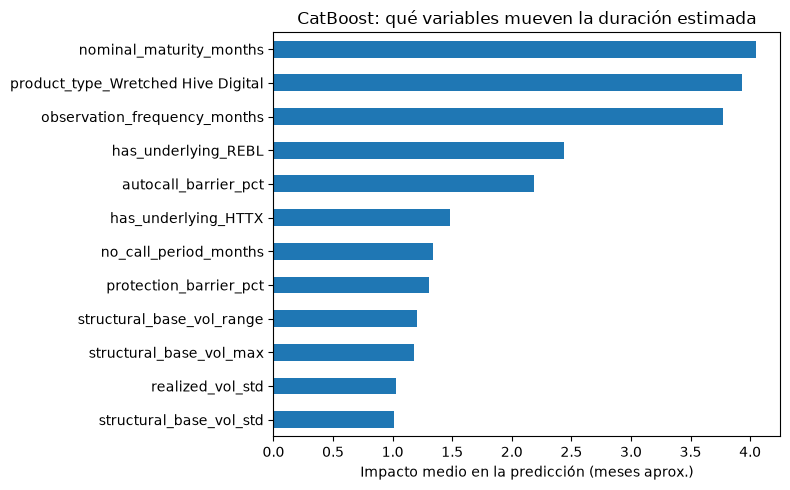


GAM - efectos lineales más fuertes (en unidades de ratio por desviación típica):
                                      term  coefficient  abs_coefficient
               linear__has_underlying_HTTX       0.1335           0.1335
                  linear__realized_vol_min      -0.1171           0.1171
           linear__structural_base_vol_max      -0.1011           0.1011
               linear__has_underlying_REBL      -0.0767           0.0767
     linear__realized_minus_structural_vol       0.0677           0.0677
               linear__has_underlying_NABO      -0.0527           0.0527
                  linear__realized_vol_std      -0.0481           0.0481
linear__product_type_Wretched Hive Digital       0.0473           0.0473
               linear__has_underlying_POBK       0.0467           0.0467
           linear__structural_base_vol_std       0.0450           0.0450


In [12]:
shap_values = model_primary.get_feature_importance(type="ShapValues", data=Pool(test[feature_columns]))
plazo_medio = float(test[MATURITY].mean())
shap_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "shap_medio_abs_ratio": np.abs(shap_values[:, :-1]).mean(axis=0),
    })
    .assign(aprox_meses=lambda d: d["shap_medio_abs_ratio"] * plazo_medio)
    .sort_values("shap_medio_abs_ratio", ascending=False)
    .reset_index(drop=True)
)
shap_importance.to_csv(REPORTS_DIR / "catboost_shap_importance.csv", index=False)
print(shap_importance.head(15).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

grafico = shap_importance.head(12).sort_values("shap_medio_abs_ratio")
ax = grafico.plot.barh(x="feature", y="aprox_meses", legend=False, figsize=(8, 5))
ax.set(xlabel="Impacto medio en la predicción (meses aprox.)", ylabel="",
       title="CatBoost: qué variables mueven la duración estimada")
plt.tight_layout()
plt.show()

# Coeficientes del GAM, ya comparables entre si porque las columnas van estandarizadas.
gam_terms = gam.named_steps["features"].get_feature_names_out()
gam_linear_effects = (
    pd.DataFrame({"term": gam_terms, "coefficient": gam.named_steps["regressor"].coef_})
    .loc[lambda d: d["term"].str.startswith("linear__")]
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)
gam_linear_effects.to_csv(REPORTS_DIR / "gam_linear_effects.csv", index=False)
print()
print("GAM - efectos lineales más fuertes (en unidades de ratio por desviación típica):")
print(gam_linear_effects.head(10).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

## 11. Guardado de artefactos

In [13]:
model_primary.save_model(str(CATBOOST_DIR / "model.cbm"))
model_p10.save_model(str(CATBOOST_DIR / "model_p10.cbm"))
model_p90.save_model(str(CATBOOST_DIR / "model_p90.cbm"))
joblib.dump(gam, GAM_DIR / "model.joblib")

feature_contract = {
    "target": TARGET,
    "unit": "months",
    # El modelo predice la fraccion del plazo; la API multiplica por nominal_maturity_months.
    "target_parametrization": "duration_ratio",
    "maturity_column": MATURITY,
    "maturity_range_months": [float(train[MATURITY].min()), float(train[MATURITY].max())],
    "ratio_cap": RATIO_CAP,
    "feature_columns": feature_columns,
    "time_column": "requested_date",
    "holdout_start": str(test_start.date()),
    "primary_model": "model.cbm",
    "quantile_models": {"p10": "model_p10.cbm", "p90": "model_p90.cbm"},
}
(CATBOOST_DIR / "feature_contract.json").write_text(
    json.dumps(feature_contract, indent=2, ensure_ascii=False), encoding="utf-8"
)
(BASELINE_DIR / "structural_baseline.json").write_text(
    json.dumps({"mean_duration_ratio": mean_ratio_train,
                "median_duration_months": median_train}, indent=2), encoding="utf-8"
)

resumen = f"""# Resultados de modelos

Holdout temporal: {test.requested_date.min():%Y-%m-%d} a {test.requested_date.max():%Y-%m-%d} ({len(test):,} RFQs).
Modelo principal: CatBoost sobre el ratio duración/plazo, {len(feature_columns)} variables.

| Modelo | MAE (meses) | IC95% | RMSE (meses) |
|---|---:|:--:|---:|
"""
resumen += "\n".join(
    f"| {r.modelo} | {r.MAE_meses:.3f} | {r.IC95_bajo:.2f} – {r.IC95_alto:.2f} | {r.RMSE_meses:.3f} |"
    for r in metrics.itertuples(index=False)
)
resumen += f"""

## Backtest de origen deslizante ({len(backtest)} ventanas de {FOLD_MONTHS} meses)

| Variante | MAE medio | Desviación entre ventanas |
|---|---:|---:|
| Baseline estructural | {backtest.MAE_estructural.mean():.3f} | {backtest.MAE_estructural.std():.3f} |
| CatBoost sin plazo | {backtest.MAE_sin_plazo.mean():.3f} | {backtest.MAE_sin_plazo.std():.3f} |
| CatBoost sobre el ratio | {backtest.MAE_principal.mean():.3f} | {backtest.MAE_principal.std():.3f} |

## Decisiones

- El plazo del producto (`nominal_maturity_months`) entra en el contrato: es un término pactado
  de la RFQ, no información del futuro. Aporta {ablation.MAE_meses.iloc[0] - ablation.MAE_meses.iloc[1]:.2f} meses de MAE.
- El modelo predice la fracción del plazo que sobrevive el producto, no los meses directamente.
  Aporta otros {ablation.MAE_meses.iloc[1] - ablation.MAE_meses.iloc[2]:.2f} meses.
- Las diferencias por debajo de ~0.5 meses no son distinguibles del ruido con este holdout.
- Se publican bandas P10-P90 con cobertura observada del {dentro:.0%}.
"""
(MODELS_DIR / "README.md").write_text(resumen, encoding="utf-8")

print("Artefactos guardados:")
for path in sorted(MODELS_DIR.rglob("*")):
    if path.is_file():
        print(f"  {path.relative_to(MODELS_DIR)}")

Artefactos guardados:
  .gitkeep
  README.md
  baseline/structural_baseline.json
  catboost/feature_contract.json
  catboost/model.cbm
  catboost/model_p10.cbm
  catboost/model_p90.cbm
  gam/model.joblib
  reports/backtest_metrics.csv
  reports/catboost_shap_importance.csv
  reports/gam_linear_effects.csv
  reports/holdout_metrics.csv
  reports/volatility_trend_experiment.md
